# Train trên GPU RTX5090 - Chứng minh Reproducibility Issues

**GPU Target**: NVIDIA GeForce RTX 5090  
**Compute Capability**: 10.0+ (Blackwell architecture)  
**TF32 Support**: ✅ Hỗ trợ (Blackwell architecture)

**Mục tiêu**: Train cùng mô hình, cùng seed trên GPU RTX5090 và so sánh với các GPU khác.

**Lưu ý**: 
- RTX 5090 hỗ trợ TF32 (mặc định bật), có thể tắt để so sánh
- Chạy notebook này trên hệ thống có GPU RTX5090
- Kết quả sẽ được lưu vào `results/` để so sánh với các GPU khác


## 1. Kiểm tra GPU và thiết lập môi trường


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import json
from datetime import datetime
import os
import functools

# Kiểm tra GPU
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_capability = torch.cuda.get_device_capability(0)
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {gpu_name}")
    print(f"GPU Compute Capability: {gpu_capability}")
    
    # Kiểm tra TF32 support (RTX 5090 hỗ trợ)
    print(f"\nTF32 enabled (cuDNN): {torch.backends.cudnn.allow_tf32}")
    # Kiểm tra cuBLAS TF32 (có thể không có trong một số phiên bản PyTorch)
    if hasattr(torch.backends, 'cublas'):
        print(f"TF32 enabled (cuBLAS): {torch.backends.cublas.allow_tf32}")
    else:
        print("TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)")
    
    # Xác nhận GPU
    if "RTX 5090" not in gpu_name.upper() and "RTX5090" not in gpu_name.upper() and "5090" not in gpu_name:
        print(f"\n⚠️  CẢNH BÁO: GPU hiện tại ({gpu_name}) không phải RTX 5090!")
        print("   Notebook này được thiết kế cho NVIDIA GeForce RTX 5090.")
        print("   Vẫn tiếp tục nhưng kết quả có thể khác.")
    else:
        print(f"\n✓ Đã xác nhận: GPU RTX 5090")
else:
    print("❌ Không tìm thấy CUDA GPU!")


PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8
cuDNN version: 91002
GPU: NVIDIA GeForce RTX 5090
GPU Compute Capability: (12, 0)

TF32 enabled (cuDNN): True
TF32 enabled (cuBLAS): N/A (không hỗ trợ trong phiên bản PyTorch này)

✓ Đã xác nhận: GPU RTX 5090


## 2. Hàm thiết lập seed và môi trường


In [2]:
def set_seed(seed=42):
    """Thiết lập seed cho tất cả các RNG để đảm bảo reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def setup_environment(tf32_enabled=True, amp_enabled=False, num_workers=0):
    """
    Thiết lập môi trường với các cấu hình khác nhau
    
    Args:
        tf32_enabled: Bật/tắt TF32 (RTX 5090 hỗ trợ, có thể bật/tắt)
        amp_enabled: Bật/tắt Automatic Mixed Precision
        num_workers: Số worker cho DataLoader
    """
    # RTX 5090 hỗ trợ TF32
    torch.backends.cudnn.allow_tf32 = tf32_enabled
    # cuBLAS TF32 (có thể không có trong một số phiên bản PyTorch)
    if hasattr(torch.backends, 'cublas'):
        torch.backends.cublas.allow_tf32 = tf32_enabled
    
    config = {
        'tf32_enabled': tf32_enabled,  # RTX 5090 hỗ trợ
        'amp_enabled': amp_enabled,
        'num_workers': num_workers,
        'gpu_name': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU',
        'gpu_capability': torch.cuda.get_device_capability(0) if torch.cuda.is_available() else None
    }
    
    return config


In [3]:
# Worker init function phải ở ngoài để có thể pickle trên Windows
def _worker_init_fn(worker_id, seed_val=42):
    """Khởi tạo seed cho mỗi worker process"""
    np.random.seed(seed_val + worker_id)


## 3. Định nghĩa mô hình đơn giản (CNN cho CIFAR-10)


In [4]:
class SimpleCNN(nn.Module):
    """Mô hình CNN đơn giản với BatchNorm và Dropout để dễ thấy sự khác biệt"""
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        
        # CIFAR-10: 32x32 -> 16x16 -> 8x8 -> 4x4
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 4 * 4)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [5]:
# Override get_cifar10_loaders để sửa lỗi pickle trên Windows
def get_cifar10_loaders(batch_size=128, num_workers=0, seed=42):
    """Load CIFAR-10 với preprocessing chuẩn (fixed for Windows multiprocessing)"""
    transform_train = transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    transform_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
    ])
    
    # Set seed cho DataLoader - sử dụng functools.partial với function độc lập
    # (tránh lỗi pickle trên Windows với nested function)
    worker_init_fn = functools.partial(_worker_init_fn, seed_val=seed) if num_workers > 0 else None
    
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform_train
    )
    trainloader = DataLoader(
        trainset, batch_size=batch_size, shuffle=True, 
        num_workers=num_workers, worker_init_fn=worker_init_fn,
        persistent_workers=False, pin_memory=False
    )
    
    testset = torchvision.datasets.CIFAR10(
        root='./data', train=False, download=True, transform=transform_test
    )
    testloader = DataLoader(
        testset, batch_size=batch_size, shuffle=False, num_workers=num_workers,
        persistent_workers=False, pin_memory=False
    )
    
    return trainloader, testloader


## 4. Load dữ liệu CIFAR-10


## 5. Hàm training với logging chi tiết


In [6]:
def train_one_epoch(model, trainloader, criterion, optimizer, device, amp_enabled=False):
    """Train một epoch và trả về loss trung bình"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    scaler = torch.cuda.amp.GradScaler() if amp_enabled else None
    
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        if amp_enabled and scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / len(trainloader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc

def evaluate(model, testloader, criterion, device):
    """Evaluate trên test set"""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            test_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    test_loss = test_loss / len(testloader)
    test_acc = 100. * correct / total
    return test_loss, test_acc


## 6. Hàm train đầy đủ với logging


In [7]:
def train_model(config, seed=42, num_epochs=10, save_results=True):
    """
    Train mô hình với cấu hình cụ thể và lưu kết quả
    
    Returns:
        dict: Kết quả training bao gồm loss, accuracy theo epoch
    """
    # Setup
    set_seed(seed)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Load data
    trainloader, testloader = get_cifar10_loaders(
        batch_size=128, 
        num_workers=config['num_workers'],
        seed=seed
    )
    
    # Model
    model = SimpleCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Training history
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': [],
        'config': config,
        'seed': seed
    }
    
    print(f"\n{'='*60}")
    print(f"Training trên GPU RTX5090 với cấu hình:")
    print(f"  GPU: {config['gpu_name']}")
    print(f"  TF32: {config['tf32_enabled']} (RTX 5090 hỗ trợ)")
    print(f"  AMP: {config['amp_enabled']}")
    print(f"  Num Workers: {config['num_workers']}")
    print(f"  Seed: {seed}")
    print(f"{'='*60}\n")
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, trainloader, criterion, optimizer, device, 
            amp_enabled=config['amp_enabled']
        )
        test_loss, test_acc = evaluate(model, testloader, criterion, device)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['test_loss'].append(test_loss)
        history['test_acc'].append(test_acc)
        
        print(f"Epoch {epoch+1}/{num_epochs}:")
        print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")
    
    # Lưu kết quả
    if save_results:
        os.makedirs('results', exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f"results/train_RTX5090_tf32_{config['tf32_enabled']}_amp_{config['amp_enabled']}_{timestamp}.json"
        
        with open(filename, 'w') as f:
            json.dump(history, f, indent=2)
        print(f"\n✓ Kết quả đã lưu: {filename}")
        print(f"  → Copy file này để so sánh với các GPU khác trong notebook 03")
    
    return history


## 7. Chạy thử nghiệm trên GPU RTX5090

### 7.1 Test với cấu hình mặc định (TF32 bật - mặc định cho RTX 5090)


In [8]:
# Test 1: Cấu hình mặc định cho RTX5090 (TF32 bật)
config_default = setup_environment(tf32_enabled=True, amp_enabled=False, num_workers=0)
history_default = train_model(config_default, seed=42, num_epochs=10)



Training trên GPU RTX5090 với cấu hình:
  GPU: NVIDIA GeForce RTX 5090
  TF32: True (RTX 5090 hỗ trợ)
  AMP: False
  Num Workers: 0
  Seed: 42

Epoch 1/10:
  Train Loss: 1.4627, Train Acc: 46.28%
  Test Loss: 1.0892, Test Acc: 60.47%
Epoch 2/10:
  Train Loss: 1.1363, Train Acc: 58.91%
  Test Loss: 1.0619, Test Acc: 61.92%
Epoch 3/10:
  Train Loss: 1.0195, Train Acc: 63.65%
  Test Loss: 0.8706, Test Acc: 68.62%
Epoch 4/10:
  Train Loss: 0.9477, Train Acc: 66.26%
  Test Loss: 0.8021, Test Acc: 71.75%
Epoch 5/10:
  Train Loss: 0.9012, Train Acc: 68.02%
  Test Loss: 0.7894, Test Acc: 72.36%
Epoch 6/10:
  Train Loss: 0.8561, Train Acc: 69.70%
  Test Loss: 0.7610, Test Acc: 73.18%
Epoch 7/10:
  Train Loss: 0.8245, Train Acc: 70.69%
  Test Loss: 0.7109, Test Acc: 75.00%
Epoch 8/10:
  Train Loss: 0.7969, Train Acc: 71.96%
  Test Loss: 0.7116, Test Acc: 75.18%
Epoch 9/10:
  Train Loss: 0.7728, Train Acc: 72.80%
  Test Loss: 0.6996, Test Acc: 75.71%
Epoch 10/10:
  Train Loss: 0.7468, Train Acc:

### 7.2 Test với num_workers=0 (để loại bỏ non-determinism từ DataLoader)


In [9]:
# Test 2: TF32 tắt để so sánh
config_no_tf32 = setup_environment(tf32_enabled=False, amp_enabled=False, num_workers=0)
history_no_tf32 = train_model(config_no_tf32, seed=42, num_epochs=10)

# Test 3: num_workers=0
config_no_workers = setup_environment(tf32_enabled=True, amp_enabled=False, num_workers=0)
history_no_workers = train_model(config_no_workers, seed=42, num_epochs=10)



Training trên GPU RTX5090 với cấu hình:
  GPU: NVIDIA GeForce RTX 5090
  TF32: False (RTX 5090 hỗ trợ)
  AMP: False
  Num Workers: 0
  Seed: 42

Epoch 1/10:
  Train Loss: 1.4605, Train Acc: 46.28%
  Test Loss: 1.0937, Test Acc: 60.07%
Epoch 2/10:
  Train Loss: 1.1380, Train Acc: 59.03%
  Test Loss: 1.0079, Test Acc: 63.94%
Epoch 3/10:
  Train Loss: 1.0219, Train Acc: 63.50%
  Test Loss: 0.8627, Test Acc: 69.71%
Epoch 4/10:
  Train Loss: 0.9514, Train Acc: 66.25%
  Test Loss: 0.7930, Test Acc: 71.78%
Epoch 5/10:
  Train Loss: 0.8995, Train Acc: 68.08%
  Test Loss: 0.7675, Test Acc: 72.96%
Epoch 6/10:
  Train Loss: 0.8602, Train Acc: 69.68%
  Test Loss: 0.7886, Test Acc: 71.88%
Epoch 7/10:
  Train Loss: 0.8261, Train Acc: 70.73%
  Test Loss: 0.7254, Test Acc: 73.96%
Epoch 8/10:
  Train Loss: 0.7942, Train Acc: 71.90%
  Test Loss: 0.6799, Test Acc: 75.99%
Epoch 9/10:
  Train Loss: 0.7746, Train Acc: 72.64%
  Test Loss: 0.7000, Test Acc: 75.46%
Epoch 10/10:
  Train Loss: 0.7525, Train Acc

## 8. So sánh kết quả trên RTX5090


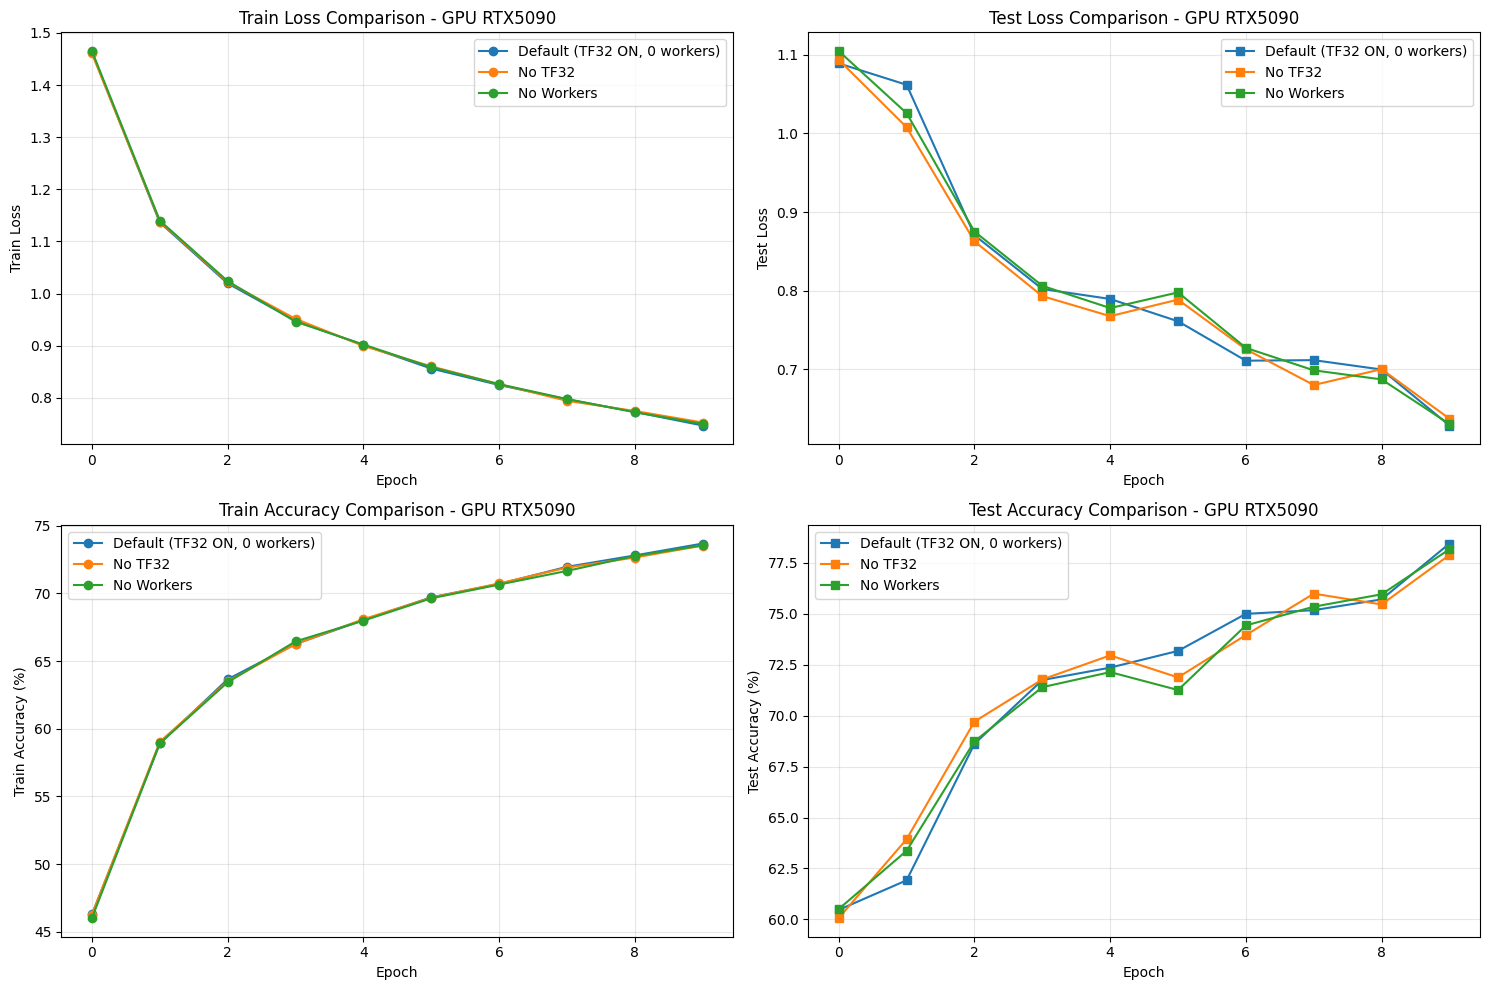


BẢNG SO SÁNH KẾT QUẢ CUỐI CÙNG - GPU RTX5090
Cấu hình                                 Train Loss   Test Loss    Test Acc    
--------------------------------------------------------------------------------
Default (TF32 ON, 0 workers)             0.7468       0.6284       78.45       %
No TF32                                  0.7525       0.6370       77.89       %
No Workers                               0.7499       0.6302       78.17       %


In [10]:
def compare_results(histories, labels):
    """So sánh và visualize kết quả từ nhiều lần train"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Train Loss
    ax = axes[0, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_loss'], label=label, marker='o')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Loss')
    ax.set_title('Train Loss Comparison - GPU RTX5090')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Test Loss
    ax = axes[0, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_loss'], label=label, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Loss')
    ax.set_title('Test Loss Comparison - GPU RTX5090')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Train Accuracy
    ax = axes[1, 0]
    for hist, label in zip(histories, labels):
        ax.plot(hist['train_acc'], label=label, marker='o')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train Accuracy (%)')
    ax.set_title('Train Accuracy Comparison - GPU RTX5090')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Test Accuracy
    ax = axes[1, 1]
    for hist, label in zip(histories, labels):
        ax.plot(hist['test_acc'], label=label, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Test Accuracy Comparison - GPU RTX5090')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('results/comparison_RTX5090.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # In bảng so sánh
    print("\n" + "="*80)
    print("BẢNG SO SÁNH KẾT QUẢ CUỐI CÙNG - GPU RTX5090")
    print("="*80)
    print(f"{'Cấu hình':<40} {'Train Loss':<12} {'Test Loss':<12} {'Test Acc':<12}")
    print("-"*80)
    for hist, label in zip(histories, labels):
        final_train_loss = hist['train_loss'][-1]
        final_test_loss = hist['test_loss'][-1]
        final_test_acc = hist['test_acc'][-1]
        print(f"{label:<40} {final_train_loss:<12.4f} {final_test_loss:<12.4f} {final_test_acc:<12.2f}%")
    print("="*80)

# So sánh các kết quả
histories_to_compare = [history_default, history_no_tf32, history_no_workers]
labels_to_compare = [
    f"Default (TF32 ON, 0 workers)",
    f"No TF32",
    f"No Workers"
]

compare_results(histories_to_compare, labels_to_compare)


## 9. Kết luận cho GPU RTX5090

**Đặc điểm GPU RTX5090**:
- Compute Capability: 10.0+ (Blackwell architecture)
- ✅ Hỗ trợ TF32 (Blackwell architecture)
- ✅ Hỗ trợ FP32 và FP16 (với AMP)

**Kết quả**:
- Kết quả đã được lưu vào thư mục `results/`
- File JSON có thể được dùng để so sánh với các GPU khác trong notebook `04_analyze_cross_gpu_results.ipynb`

**Bước tiếp theo**:
1. Chạy các notebook tương tự trên GPU khác (L4, A100, RTX 3060, RTX 5090)
2. Copy tất cả file JSON vào cùng thư mục `results/`
3. Chạy notebook `04_analyze_cross_gpu_results.ipynb` để so sánh
